In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/propre/offres_finales.csv")
df.head()

,titre,entreprise,secteur,ville,contrat,date_publication,lien,competences
0,Technicien Soufflage,groupe-topinter,"Maintenance, Entretien, Contrôle | Industrie M...",Dakar,CDI,2026-04-21,https://senjob.com/sn/jobseekers/technicien-so...,"autonomie, organisation"
1,COMMERCIAL VSR,groupe-topinter,"Commercial, Vente, Business developpement | Di...",Dakar,Stage,2026-04-21,https://senjob.com/sn/jobseekers/commercial-vs...,"excel, communication, autonomie, dynamisme, ré..."
2,Développeur Fullstack Java/Vue js,Confidentiel,"Informatique, Télécoms, Réseaux | Industrie In...",Dakar,Stage,2026-04-01,https://senjob.com/sn/jobseekers/développeur-f...,"java, sql, excel, spring boot, vue.js, api res..."
3,04 Assistant(e)s Techniques SAME (MATAM),Confidentiel,"Administration, Services généraux | Qualité, S...",Matam,CDD,2026-04-24,https://senjob.com/sn/jobseekers/04-assistant-...,"sage, communication, travail en équipe, rigueu..."
4,CHEF DE SECTEUR JUNIOR,groupe-topinter,"Commercial, Vente, Business developpement | In...",Dakar,CDD,2026-04-08,https://senjob.com/sn/jobseekers/chef-de-secte...,marketing


## Nombre d'offre par secteur 

Top 10 secteurs :
secteur
Agences de recrutement                      521
Organisations non-gouvernementales (ONG)    492
Non précisé                                 296
Organismes internationaux                   225
Gestion des ressources humaines             214
Vente en ligne                              196
Travail temporaire - Intérim                150
Banques                                      99
Enseignement supérieur - Université          93
Administrations                              81
Name: count, dtype: int64


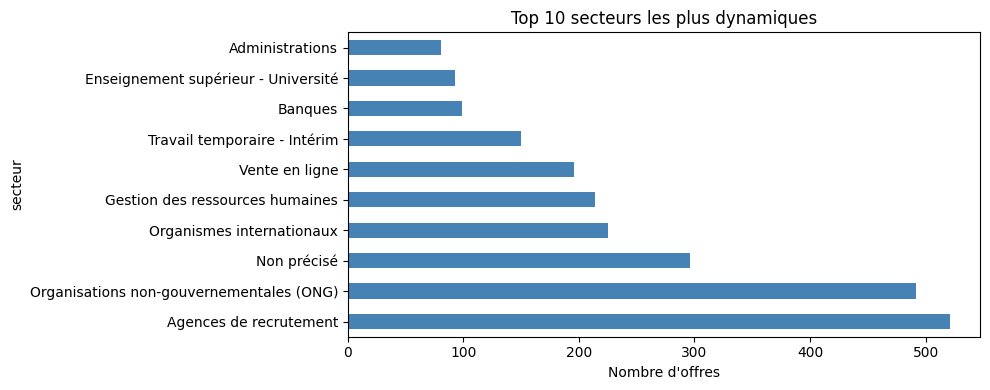

In [2]:
secteurs = df['secteur'].value_counts().head(10)

print("Top 10 secteurs :")
print(secteurs)

plt.figure(figsize=(10, 4))
secteurs.plot(kind='barh', color='steelblue')
plt.title("Top 10 secteurs les plus dynamiques")
plt.xlabel("Nombre d'offres")
plt.tight_layout()
plt.show()

## op 10 compétences demandées

Top 10 compétences :
communication    1802
excel            1792
organisation     1734
analyse          1602
français         1418
anglais          1332
rigueur          1119
reporting         845
finance           807
autonomie         801
dtype: int64


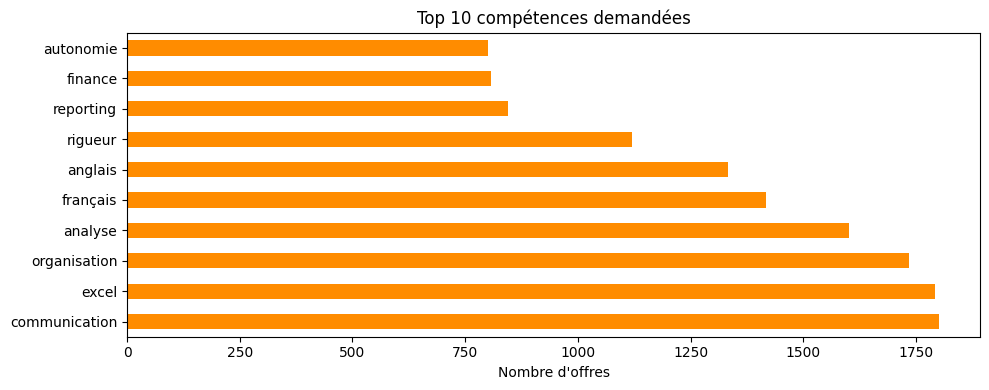

In [3]:
from collections import Counter

# Séparer les compétences et compter
toutes_competences = df['competences'].dropna()
toutes_competences = toutes_competences[toutes_competences != "Non précisé"]

compteur = Counter()
for comp in toutes_competences:
    for c in comp.split(", "):
        compteur[c.strip()] += 1

top10 = pd.Series(compteur).sort_values(ascending=False).head(10)

print("Top 10 compétences :")
print(top10)

plt.figure(figsize=(10, 4))
top10.plot(kind='barh', color='darkorange')
plt.title("Top 10 compétences demandées")
plt.xlabel("Nombre d'offres")
plt.tight_layout()
plt.show()

## répartition géographique

Répartition géographique :
ville
Dakar           4699
Hors Sénégal      81
Thiès             48
Non précisé       11
Saint-Louis        9
Mbour              8
Kaolack            7
Louga              6
Diamniadio         4
Ziguinchor         4
Name: count, dtype: int64


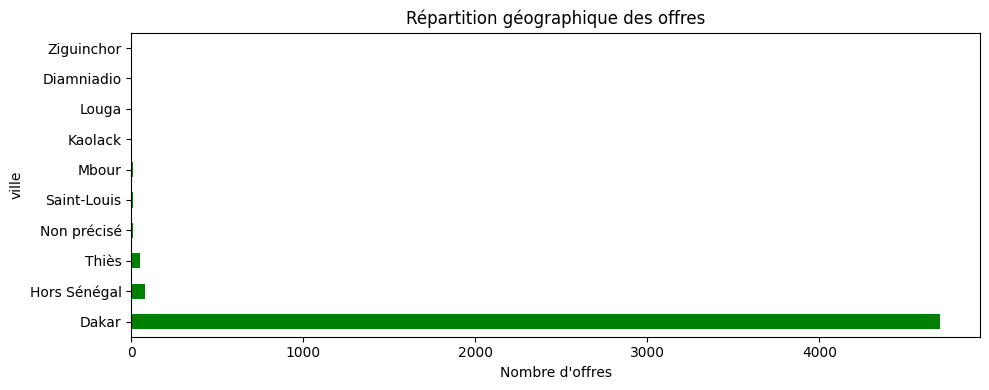

In [4]:
villes = df['ville'].value_counts().head(10)

print("Répartition géographique :")
print(villes)

plt.figure(figsize=(10, 4))
villes.plot(kind='barh', color='green')
plt.title("Répartition géographique des offres")
plt.xlabel("Nombre d'offres")
plt.tight_layout()
plt.show()

Évolution mensuelle :
mois
2024-09     28
2024-10     46
2024-11     41
2024-12     10
2025-01    289
2025-02    302
2025-03    300
2025-04    321
2025-05    238
2025-06    286
2025-07    242
2025-08    168
2025-09    239
2025-10    331
2025-11    133
2025-12    240
2026-01    262
2026-02    234
2026-03    361
2026-04    833
Freq: M, dtype: int64


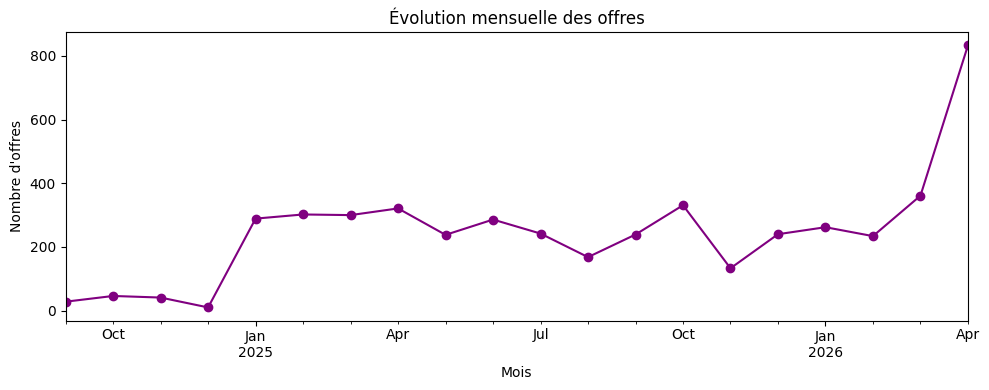

In [5]:
df['date_publication'] = pd.to_datetime(df['date_publication'])
df['mois'] = df['date_publication'].dt.to_period('M')

evolution = df.groupby('mois').size().sort_index()

print("Évolution mensuelle :")
print(evolution)

plt.figure(figsize=(10, 4))
evolution.plot(kind='line', color='purple', marker='o')
plt.title("Évolution mensuelle des offres")
plt.xlabel("Mois")
plt.ylabel("Nombre d'offres")
plt.tight_layout()
plt.show()

# KPIs

In [6]:
# Secteur dominant
secteur_dominant = df['secteur'].value_counts().index[0]
nb_offres = df['secteur'].value_counts().iloc[0]

print(f"Secteur dominant : {secteur_dominant}")
print(f"Nombre d'offres : {nb_offres}")

Secteur dominant : Agences de recrutement
Nombre d'offres : 521


In [7]:
# Compétence la plus recherchée
competence_top = top10.index[0]
nb_competence = top10.iloc[0]

print(f"Compétence la plus recherchée : {competence_top}")
print(f"Nombre d'offres : {nb_competence}")

Compétence la plus recherchée : communication
Nombre d'offres : 1802


In [8]:
# Ville avec le plus d'opportunités
ville_top = df['ville'].value_counts().index[0]
nb_ville = df['ville'].value_counts().iloc[0]

print(f"Ville avec le plus d'opportunités : {ville_top}")
print(f"Nombre d'offres : {nb_ville}")

Ville avec le plus d'opportunités : Dakar
Nombre d'offres : 4699


Croissance mensuelle des offres (%) :
mois
2024-09        NaN
2024-10      64.29
2024-11     -10.87
2024-12     -75.61
2025-01    2790.00
2025-02       4.50
2025-03      -0.66
2025-04       7.00
2025-05     -25.86
2025-06      20.17
2025-07     -15.38
2025-08     -30.58
2025-09      42.26
2025-10      38.49
2025-11     -59.82
2025-12      80.45
2026-01       9.17
2026-02     -10.69
2026-03      54.27
2026-04     130.75
Freq: M, dtype: float64


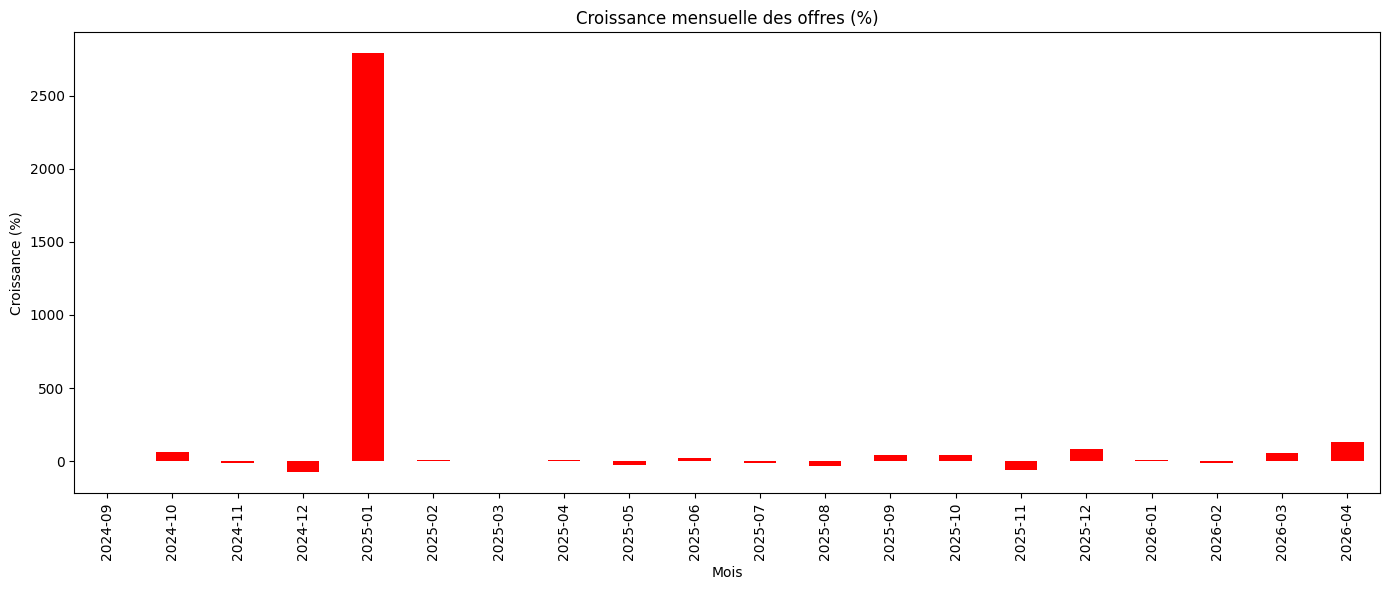

In [9]:
# Croissance mensuelle des offres
croissance = evolution.pct_change() * 100
croissance = croissance.round(2)

print("Croissance mensuelle des offres (%) :")
print(croissance)

plt.figure(figsize=(14, 6))
croissance.plot(kind='bar', color='red')
plt.title("Croissance mensuelle des offres (%)")
plt.xlabel("Mois")
plt.ylabel("Croissance (%)")
plt.tight_layout()
plt.show()